# Deep Q-Learning en el entorno LunarLander-v3

*Description*: Implementación y análisis del algoritmo Deep Q-Learning para resolver el problema LunarLander-v3.

    Authors: Ginés Carrillo Ibáñez, Yago Ibarrola Lapeña, Aarón Palomar Peña
    Emails: gines.carrilloi@um.es, yago.ibarrolal@um.es, aaron.p.p@um.es
    Date: 2026/02/22

## Preparación del entorno

En primer lugar instalamos las dependencias necesarias para ejecutar el código. En este caso, necesitamos instalar la biblioteca `gymnasium` y su extensión `box2d` para poder utilizar el entorno LunarLander-v3:

Realizamos los import necesarios, destacando en este caso la inclusión de `torch` para la implementación de la red neuronal que utilizaremos como función aproximadora en nuestro agente de Deep Q-Learning:

In [1]:
import sys
if 'google.colab' in sys.modules:
    # Definimos que el entorno es Colab
    en_colab = True
    print("Ejecutando en Google Colab")
else:
    # Definimos que el entorno es local
    en_colab = False
    print("Ejecutando en entorno local")

Ejecutando en Google Colab


In [2]:
if en_colab:
    #@title Copiar el repositorio.
    print("Clonando el repositorio, tiempo estimado: 1-2 minutos...")
    !git clone https://github.com/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar.git
    !cd EML_Carrillo_Ibarrola_Palomar/

    #@title Importamos todas las clases y funciones
    import sys
    # Añadir los directorio fuentes al path de Python
    sys.path.append('/content/EML_Carrillo_Ibarrola_Palomar/entornos_complejos/src/')
    # Verificar que se han añadido correctamente
    print(sys.path)

    !pip install -r ./EML_Carrillo_Ibarrola_Palomar/requirements.txt

    dir_base = "./EML_Carrillo_Ibarrola_Palomar/entornos_complejos"
else:
    dir_base = ".."

Clonando el repositorio, tiempo estimado: 1-2 minutos...
Cloning into 'EML_Carrillo_Ibarrola_Palomar'...
remote: Enumerating objects: 1550, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 1550 (delta 13), reused 29 (delta 6), pack-reused 1501 (from 3)
Receiving objects: 100% (1550/1550), 1.32 GiB | 20.41 MiB/s, done.
Resolving deltas: 100% (676/676), done.
Updating files: 100% (331/331), done.
['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/EML_Carrillo_Ibarrola_Palomar/entornos_complejos/src/']
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 53.6 MB/s eta 0:00:00


In [3]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
from agents import LunarAgentDeepQLearning
from utils import plot_training_metrics
import gymnasium as gym

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
np.random.default_rng(SEED)
torch.manual_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Fijamos las semillas para PyTorch (cubriendo tanto CPU como múltiples GPUs)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


if torch.cuda.is_available():
    # Forzamos a cuDNN a utilizar algoritmos deterministas (puede impactar ligeramente el rendimiento)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


## Ejecución del experimento

El agente se entrena utilizando el algoritmo **Deep Q-Learning**  y el uso de una memoria de experiencia (Experience Replay).

La red neuronal utilizada contiene:

* una capa de entrada de tamaño **8** (dimensión del estado),
* **dos capas ocultas** totalmente conectadas de 64 neuronas con activación ReLU,
* una capa de salida con **4 neuronas** que representan los valores ($Q(s,a)$) para cada acción.

Durante el entrenamiento:

* Se ejecutan **`n_episodes` episodios** (definido en 1500 episodios) con un máximo de 1000 iteraciones por episodio.
* La política utilizada es **epsilon-greedy**.
* Exploración inicial ($\epsilon_0 = 1.0$).
* Decaimiento de ($\epsilon$) con un factor de 0.995 hasta un mínimo de ($\epsilon_{min} = 0.01$).
* Factor de descuento ($\gamma = 0.99$).

En cada episodio:

1. Se reinicia el entorno y se obtiene el estado inicial.
2. El agente selecciona una acción usando **política epsilon-greedy**.
3. El entorno devuelve el nuevo estado, la recompensa y si el episodio ha terminado.
4. La transición $(s, a, r, s', \text{done})$ se almacena en la memoria de experiencia del agente.
5. Periódicamente, el agente extrae un mini-batch aleatorio de transiciones de la memoria para aprender.
6. Se calcula el valor objetivo (Target) maximizando la recompensa de la mejor acción futura (propio de **Q-Learning**):

$$target = r + \gamma \max_{a'} Q(s',a';\theta^-)$$

7. Se actualizan los parámetros de la **red local** minimizando la pérdida cuadrática frente al valor objetivo calculado:

$$\text{loss} = (Q(s,a;\theta) - target)^2$$

8. Se realiza una **actualización suave (soft update)** de los pesos de la red objetivo, acercándolos ligeramente a los de la red local para dar estabilidad al aprendizaje:

$$\theta^- \leftarrow \tau \theta + (1 - \tau) \theta^-$$

9. Se repite el proceso hasta que el episodio termina o se alcanza el máximo de pasos.
10. Al final del episodio se reduce el valor de ($\epsilon$) según el esquema de decaimiento.

Las clases de agente, red neuronal y memoria de experiencia se encuentran definidas en el archivo `/agents/lunarAgentDeepQLearning.py`.

Utilizamos la siguiente función de entrenamiento. Como detalle, mostramos la recompensa media de los últimos 100 episodios cada 100 episodios para monitorizar el progreso del agente durante el entrenamiento. Además, al finalizar el entrenamiento, se guarda el modelo entrenado en un archivo `.pth` para su posterior uso.

In [4]:
def train_agent(env, agent, n_episodes=2000, max_t=1000):
    scores = []                        # Lista con todas las puntuaciones
    scores_window = deque(maxlen=100)  # Cola para calcular la media movil de los ultimos 100

    for i_episode in range(1, n_episodes + 1):
        state, _ = env.reset(seed=i_episode)  # Reiniciamos el entorno con una semilla diferente cada episodio
        score = 0

        # Iteramos los pasos del episodio
        for t in range(max_t):
            # Solicitamos la accion al agente
            action = agent.get_action(state, agent.epsilon)
            next_state, reward, done, _, _ = env.step(action)

            # El agente procesa la transicion y aprende si es el momento
            agent.update(state, action, reward, done, next_state)

            state = next_state
            score += reward

            if done:
                break

        # Guardamos las puntuaciones y reducimos epsilon
        scores_window.append(score)
        scores.append(score)
        agent.decay_epsilon()

        # Mostramos el progreso dinamicamente
        print(f'\rEpisodio {i_episode}\tMedia ultimos 100: {np.mean(scores_window):.2f}', end="")
        if i_episode % 100 == 0:
            print(f'\rEpisodio {i_episode}\tMedia ultimos 100: {np.mean(scores_window):.2f}')


    torch.save(agent.qnetwork_local.state_dict(), dir_base+'/data/results/DeepQLearningLunarLander/deep_qlearning_lunar_lander.pth')


    return scores

In [5]:
env = gym.make('LunarLander-v3')
env.reset(seed=SEED)
state_shape = env.observation_space.shape
state_size = env.observation_space.shape[0]
number_actions = env.action_space.n
print('State shape: ', state_shape)
print('State size: ', state_size)
print('Number of actions: ', number_actions)

State shape:  (8,)
State size:  8
Number of actions:  4


In [6]:
number_episodes = 1500
maximum_number_timesteps_per_episode = 1000
epsilon_starting_value  = 1.0
epsilon_ending_value  = 0.01

discount_factor = 0.99
epsilon_decay_value = 0.995
epsilon = epsilon_starting_value
scores_on_100_episodes = deque(maxlen = 100)

env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=number_episodes)


### Deep Q-Learning con política epsilon-greedy CON epsilon decay
En primer lugar, entrenamos al agente utilizando la política epsilon-greedy con epsilon decaimiento.

In [7]:


agent = LunarAgentDeepQLearning( env = env,
                                state_size = state_size,
                                action_size = number_actions,
                                epsilon = epsilon_starting_value,
                                epsilon_decay = epsilon_decay_value,
                                final_epsilon = epsilon_ending_value,
                                discount_factor = discount_factor,
                                seed = SEED)
scores = train_agent(env,
                     agent,
                     n_episodes=number_episodes,
                     max_t=maximum_number_timesteps_per_episode,
                     )

Episodio 100	Media ultimos 100: -152.70
Episodio 200	Media ultimos 100: -82.11
Episodio 300	Media ultimos 100: -30.06
Episodio 400	Media ultimos 100: 37.98
Episodio 500	Media ultimos 100: 107.18
Episodio 600	Media ultimos 100: 145.00
Episodio 700	Media ultimos 100: 199.22
Episodio 800	Media ultimos 100: 220.64
Episodio 900	Media ultimos 100: 229.33
Episodio 1000	Media ultimos 100: 245.93
Episodio 1100	Media ultimos 100: 240.86
Episodio 1200	Media ultimos 100: 255.33
Episodio 1300	Media ultimos 100: 256.55
Episodio 1400	Media ultimos 100: 229.78
Episodio 1500	Media ultimos 100: 238.32


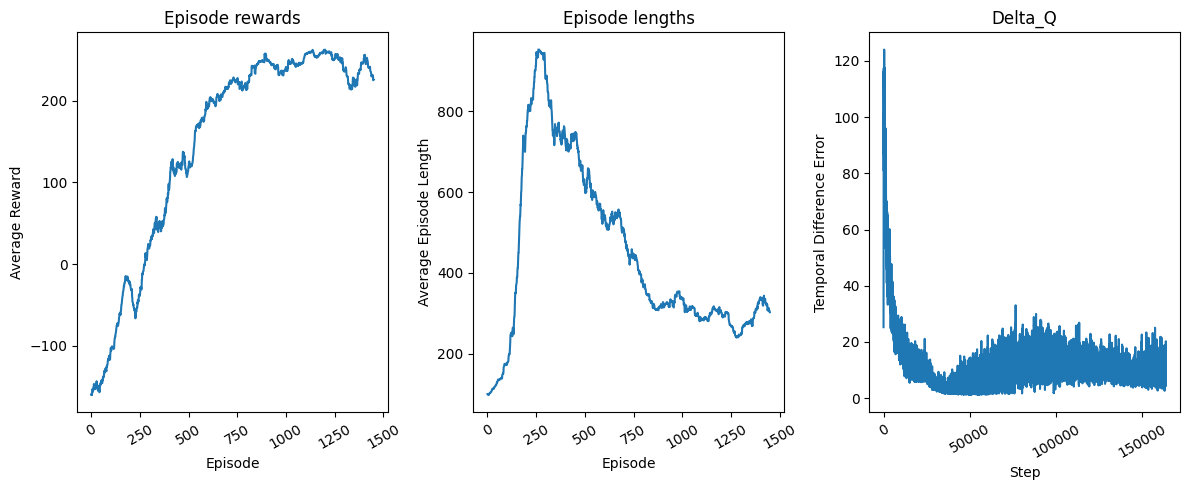

In [8]:
plot_training_metrics(env.return_queue, env.length_queue, agent.training_error, rolling_length=50)

Obtenemos una convergencia bastante rápida, alcanzando a mitad del entrenamiento recompensas medias cercanas a 200, que es el umbral para considerar que el entorno está resuelto. Al finalizar el entrenamiento, el agente obtiene una recompensa media de aproximadamente 250, unos resultados muy buenos para este entorno.

Veamos los resultados obtenidos en test con la política aprendida pero sin exploración (epsilon = 0):

In [9]:
agent.test(n_episodes=1000)


Resultados finales: 931/1000 victorias.
Recompensa media real: 247.92


Obtenemos un 93.1% de win-rate con una recompensa media de 247.31, resultados que confirman que el agente ha aprendido a resolver el entorno de manera efectiva.

### Deep Q-Learning con política epsilon-greedy SIN epsilon decay
Probamos con un agente con una política $\epsilon$-greedy simple sin decaimiento de $\epsilon$ para ver cómo se comporta en el entorno:

In [10]:
epsilon = 0.1
final_epsilon = 0.1
epsilon_decay_value = 1.0
env2 = gym.make('LunarLander-v3')
env2.reset(seed=SEED)
env2 = gym.wrappers.RecordEpisodeStatistics(env2, buffer_length=number_episodes)

agent2= LunarAgentDeepQLearning( env = env2,
                                state_size = state_size,
                                action_size = number_actions,
                                epsilon = epsilon,
                                epsilon_decay = epsilon_decay_value,
                                final_epsilon = final_epsilon,
                                discount_factor = discount_factor,
                                seed = SEED)
scores_decay = train_agent(env2,
                     agent2,
                     n_episodes=number_episodes,
                     max_t=maximum_number_timesteps_per_episode
                     )

Episodio 100	Media ultimos 100: -210.21
Episodio 200	Media ultimos 100: -163.95
Episodio 300	Media ultimos 100: -103.12
Episodio 400	Media ultimos 100: -110.66
Episodio 500	Media ultimos 100: -57.94
Episodio 600	Media ultimos 100: 68.50
Episodio 700	Media ultimos 100: 132.70
Episodio 800	Media ultimos 100: 205.96
Episodio 900	Media ultimos 100: 223.94
Episodio 1000	Media ultimos 100: 241.27
Episodio 1100	Media ultimos 100: 226.70
Episodio 1200	Media ultimos 100: 252.09
Episodio 1300	Media ultimos 100: 265.00
Episodio 1400	Media ultimos 100: 262.88
Episodio 1500	Media ultimos 100: 264.16


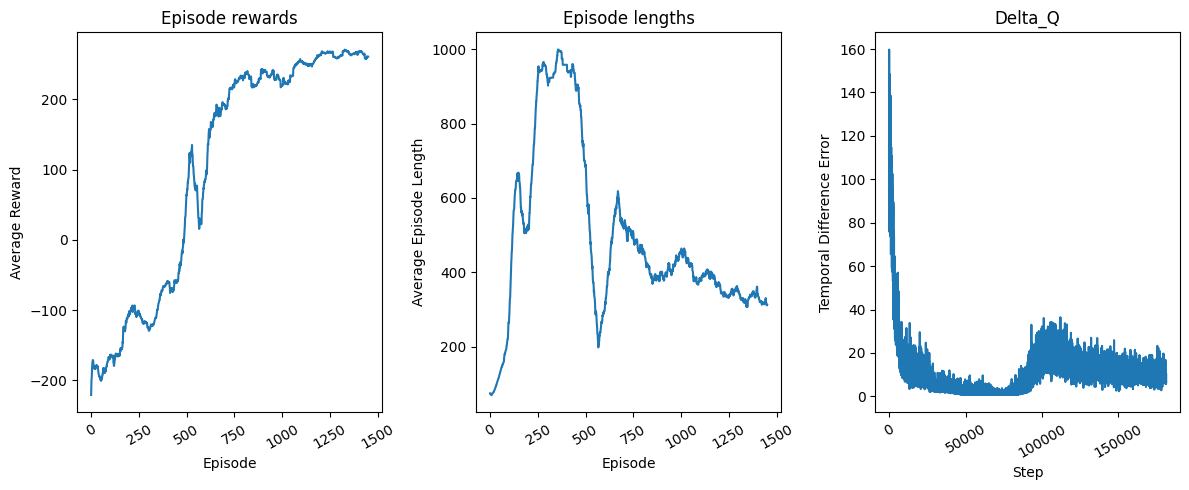

In [11]:
plot_training_metrics(env2.return_queue, env2.length_queue, agent2.training_error, rolling_length=50)

In [12]:
agent2.test(n_episodes=1000)


Resultados finales: 967/1000 victorias.
Recompensa media real: 267.12


## Visualización animada del resultado
Finalmente, visualizamos el resultado del agente entrenado en el entorno LunarLander-v3. Para ello, utilizamos la función `render()` del entorno para mostrar la animación del agente interactuando con el entorno.



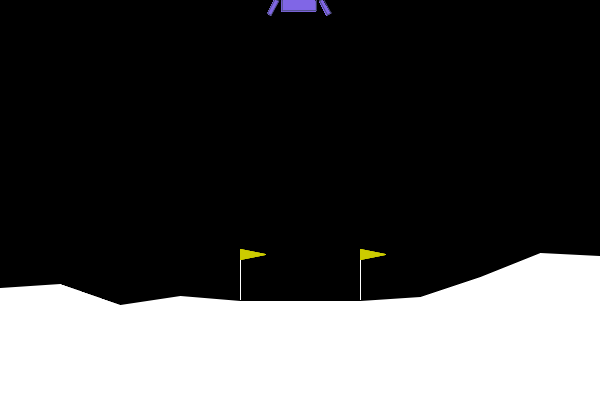

In [13]:
import io
import base64
import imageio
from IPython.display import HTML, display
import gymnasium as gym

def generate_gif_of_model(agent, env_name, path=dir_base+'/data/results/DeepQLearningLunarLander/video.gif'):
    # Instanciamos el entorno para captura de fotogramas
    env = gym.make(env_name, render_mode='rgb_array')
    state, _ = env.reset()
    done = False
    frames = []

    while not done:
        # Extraemos y almacenamos la imagen actual
        frame = env.render()
        frames.append(frame)

        # Consultamos a la red neuronal sin exploración
        action = agent.get_action(state, eps=0.0)

        # Ejecutamos el paso y desempaquetamos las variables
        state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

    env.close()

    # Generamos el archivo GIF a partir de la lista de imágenes
    imageio.mimsave(path, frames, fps=30)

# Ejecutamos la función
generate_gif_of_model(agent, 'LunarLander-v3')

def show_gif(path=dir_base+'/data/results/DeepQLearningLunarLander/video.gif'):
    # Leemos el archivo y lo preparamos para incrustar
    try:
        gif_file = io.open(path, 'r+b').read()
        encoded = base64.b64encode(gif_file)

        # Mostramos la imagen codificada en base64 en la celda
        display(HTML(data='''<img src="data:image/gif;base64,{0}" alt="Lunar Lander GIF" style="height: 400px;">'''.format(encoded.decode('ascii'))))
    except FileNotFoundError:
        print("No se pudo encontrar el GIF. Revisa la ruta del directorio.")

# Mostramos el resultado
show_gif()

## Comparaciones extra
Vamos a comparar a continuación cómo afecta tanto el factor de descuento ($\gamma$) como el uso de distintos valores de decay para el epsilon.

### Comparación con distintos factores de descuento ($\gamma$)
En esta sección, comparamos el rendimiento del agente utilizando diferentes valores para el factor de descuento ($\gamma$).

Probamos con $\gamma = 0.9$, $\gamma = 0.99$ y $\gamma = 0.999$.

In [14]:
grid_discount_factor = [0.9, 0.99, 0.999]
n_episodes =  1000

epsilon_starting_value  = 1.0
epsilon_ending_value  = 0.01
epsilon_decay_value = 0.995

reward_histories = {}
env = gym.make('LunarLander-v3')
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)


for discount_factor in grid_discount_factor:
    env.reset(seed=SEED)
    print(f"Entrenando con discount factor: {discount_factor}")
    agent = LunarAgentDeepQLearning( env = env,
                                    state_size = state_size,
                                    action_size = number_actions,
                                    epsilon = epsilon_starting_value,
                                    epsilon_decay = epsilon_decay_value,
                                    final_epsilon = epsilon_ending_value,
                                    discount_factor = discount_factor,
                                    seed = SEED)
    scores = train_agent(env,
                         agent,
                         n_episodes=n_episodes,
                         max_t=maximum_number_timesteps_per_episode,
                         )
    reward_histories[discount_factor] = scores

Entrenando con discount factor: 0.9
Episodio 100	Media ultimos 100: -151.71
Episodio 200	Media ultimos 100: -96.21
Episodio 300	Media ultimos 100: -44.21
Episodio 400	Media ultimos 100: -35.00
Episodio 500	Media ultimos 100: -50.54
Episodio 600	Media ultimos 100: -77.92
Episodio 700	Media ultimos 100: -95.63
Episodio 800	Media ultimos 100: -94.65
Episodio 900	Media ultimos 100: -93.08
Episodio 1000	Media ultimos 100: -108.35
Entrenando con discount factor: 0.99
Episodio 100	Media ultimos 100: -152.70
Episodio 200	Media ultimos 100: -82.11
Episodio 300	Media ultimos 100: -30.06
Episodio 400	Media ultimos 100: 37.98
Episodio 500	Media ultimos 100: 107.18
Episodio 600	Media ultimos 100: 145.00
Episodio 700	Media ultimos 100: 199.22
Episodio 800	Media ultimos 100: 220.64
Episodio 900	Media ultimos 100: 229.33
Episodio 1000	Media ultimos 100: 245.93
Entrenando con discount factor: 0.999
Episodio 100	Media ultimos 100: -150.48
Episodio 200	Media ultimos 100: -100.09
Episodio 300	Media ultimo

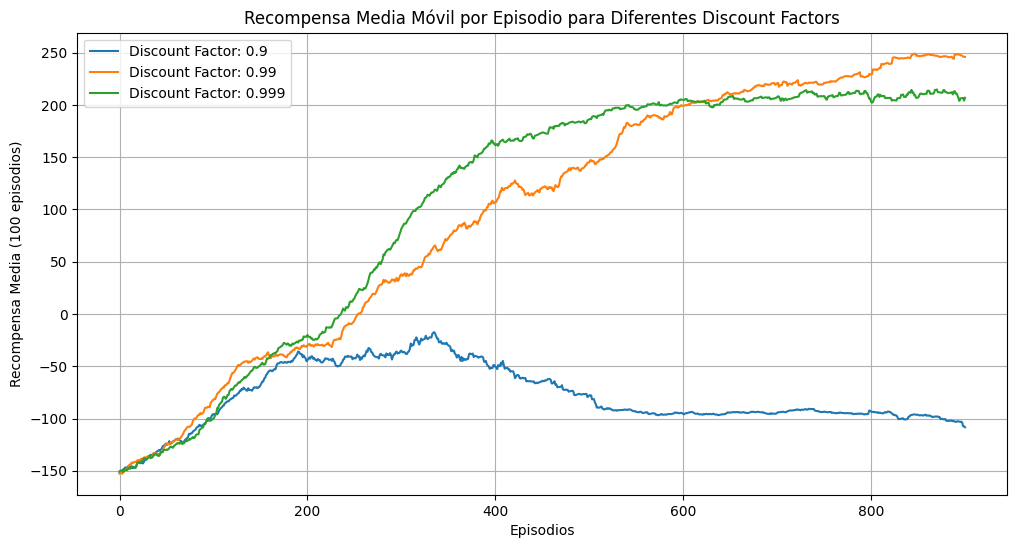

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Preparamos la figura principal
plt.figure(figsize=(12, 6))

# Iteramos sobre los historiales para aplicar el suavizado y plotear
for discount_factor, rewards in reward_histories.items():
    window = 100

    # Calculamos la media movil adaptativa
    if len(rewards) >= window:
        recompensas_suavizadas = np.convolve(rewards, np.ones(window)/window, mode='valid')
    else:
        recompensas_suavizadas = rewards

    # Trazamos la linea correspondiente a este hiperparametro
    plt.plot(recompensas_suavizadas, label=f'Discount Factor: {discount_factor}')

# Configuramos las etiquetas y la leyenda de la grafica
plt.xlabel('Episodios')
plt.ylabel('Recompensa Media (100 episodios)')
plt.title('Recompensa Media Móvil por Episodio para Diferentes Discount Factors')
plt.legend()
plt.grid()

# Mostramos el resultado final
plt.show()

Vamos a analizarlos uno a uno:
- $\gamma = 0.9$
  
    Con un factor de descuento de $\gamma = 0.9$, el agente comienza aprendiendo ligeramente, mejorando su puntuación hasta rozas los -25 en el episodio 250, situándose en este momento en un nivel similar al resto de agentes. Sin embargo, a partir de este punto el aprendizaje se estanca y la recompensa vuelve a caer, estabilizándose en torno a los -110 puntos.

    Esto ocurre porque un valor de $\gamma$ tan bajo hace que el agente se enfoque más en las recompensas inmediatas. En LunarLander, la recompensa más importante (los +100 puntos por aterrizar o los -100 por estrellarse) se otorga al final del episodio. Con un descuento tan pronunciado, el valor de esa recompensa futura decae muy rápido en el cálculo de la Ecuación de Bellman. Por tanto, el agente no logra asociar las maniobras iniciales de estabilización con el resultado final del aterrizaje, lo que suele llevar a un comportamiento donde simplemente se gasta combustible flotando sin rumbo o se deja caer para terminar rápido.

- $\gamma = 0.99$
  
    Muestra una curva de aprendizaje mucho mejor. Supera la barrera de los 0 puntos alrededor del episodio 300 y alcanza un pico cercano a los 190 puntos sobre el episodio 450, estabilizándose después en el rango de 150 a 180 puntos.

    Este valor de $\gamma$ es más adecuado para este entorno, ya que permite al agente ser lo suficientemente previsor como para entender que debe controlar el descenso gradualmente para obtener la recompensa final.

- $\gamma = 0.999$

    Es claramente la configuración ganadora. La curva asciende más rápido (cruza los 0 puntos en el episodio 230 aproximadamente) y alcanza puntuaciones medias por encima de 200 puntos alrededor del episodio 600, llegando a picos de casi 240 puntos de media.

    Un $\gamma = 0.999$ indica que el agente valora una recompensa lejana casi tanto como una inmediata. Para este entorno, esto parece ser muy beneficioso, pues las decisiones tomadas en el segundo 1 del vuelo son directamente responsables de si el módulo aterriza suavemente entre las banderas al final del episodio.

### Comparación con distintos valores de decay para el epsilon
En esta sección, comparamos el rendimiento del agente utilizando diferentes valores para el decay del epsilon en la política epsilon-greedy.
Probamos con decay = 0.9, decay = 0.99 y decay = 0.999.


In [16]:
grid_epsilon_decay = [0.9, 0.99, 0.999]
n_episodes =  1000

epsilon_starting_value  = 1.0
epsilon_ending_value  = 0.01
discount_factor = 0.99

reward_histories = {}
env = gym.make('LunarLander-v3')
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)


for epsilon_decay in grid_epsilon_decay:
    env.reset(seed=SEED)
    print(f"Entrenando con epsilon decay: {epsilon_decay}")
    agent = LunarAgentDeepQLearning( env = env,
                                    state_size = state_size,
                                    action_size = number_actions,
                                    epsilon = epsilon_starting_value,
                                    epsilon_decay = epsilon_decay,
                                    final_epsilon = epsilon_ending_value,
                                    discount_factor = discount_factor,
                                    seed = SEED)
    scores = train_agent(env,
                         agent,
                         n_episodes=n_episodes,
                         max_t=maximum_number_timesteps_per_episode,
                         )
    reward_histories[epsilon_decay] = scores

Entrenando con epsilon decay: 0.9
Episodio 100	Media ultimos 100: -307.02
Episodio 200	Media ultimos 100: -104.61
Episodio 300	Media ultimos 100: -113.06
Episodio 400	Media ultimos 100: -100.10
Episodio 500	Media ultimos 100: -66.93
Episodio 600	Media ultimos 100: -31.62
Episodio 700	Media ultimos 100: -30.15
Episodio 800	Media ultimos 100: -20.62
Episodio 900	Media ultimos 100: -12.29
Episodio 1000	Media ultimos 100: -16.39
Entrenando con epsilon decay: 0.99
Episodio 100	Media ultimos 100: -176.64
Episodio 200	Media ultimos 100: -94.02
Episodio 300	Media ultimos 100: -50.17
Episodio 400	Media ultimos 100: -45.03
Episodio 500	Media ultimos 100: -25.52
Episodio 600	Media ultimos 100: -29.56
Episodio 700	Media ultimos 100: -16.85
Episodio 800	Media ultimos 100: 93.82
Episodio 900	Media ultimos 100: 188.10
Episodio 1000	Media ultimos 100: 182.65
Entrenando con epsilon decay: 0.999
Episodio 100	Media ultimos 100: -184.45
Episodio 200	Media ultimos 100: -150.95
Episodio 300	Media ultimos 10

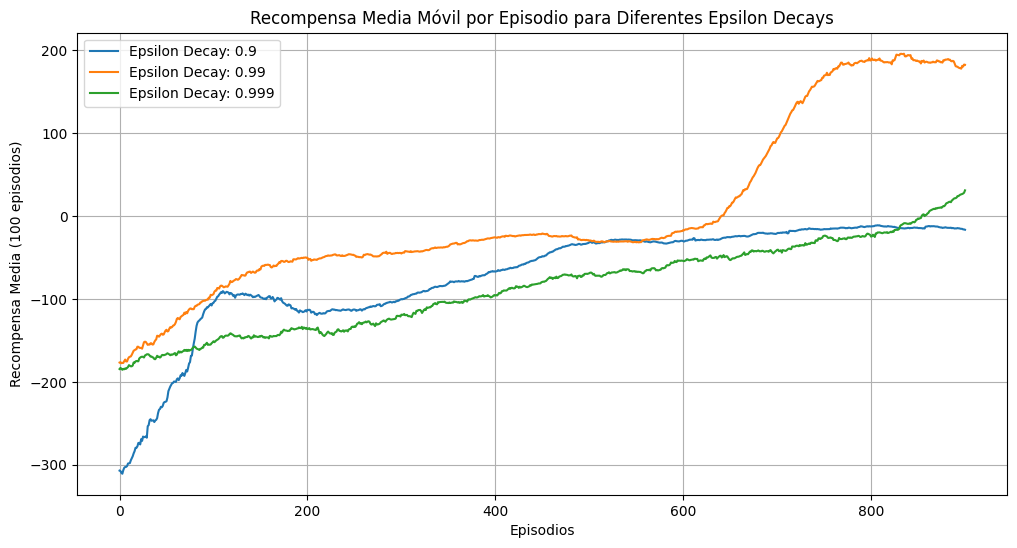

In [17]:

# Preparamos la figura principal
plt.figure(figsize=(12, 6))

# Iteramos sobre los historiales para aplicar el suavizado y plotear
for epsilon_decay, rewards in reward_histories.items():
    window = 100

    # Calculamos la media movil adaptativa
    if len(rewards) >= window:
        recompensas_suavizadas = np.convolve(rewards, np.ones(window)/window, mode='valid')
    else:
        recompensas_suavizadas = rewards

    # Trazamos la linea correspondiente a este hiperparametro
    plt.plot(recompensas_suavizadas, label=f'Epsilon Decay: {epsilon_decay}')

# Configuramos las etiquetas y la leyenda de la grafica
plt.xlabel('Episodios')
plt.ylabel('Recompensa Media (100 episodios)')
plt.title('Recompensa Media Móvil por Episodio para Diferentes Epsilon Decays')
plt.legend()
plt.grid()

# Mostramos el resultado final
plt.show()

Veamos los resultados obtenidos:
- Decay = 0.9

    Con un decay de 0.9, el agente reduce su epsilon de manera bastante rápida, alcanzando un valor cercano a 0.01 alrededor del episodio 50. Esto hace que el agente deje de explorar muy pronto, lo que se refleja en una curva de aprendizaje que apenas mejora después de los primeros episodios, estabilizándose en torno a los 0 puntos.

- Decay = 0.99

    Muestra la curva de aprendizaje perfecta. Empieza explorando (puntuaciones negativas), pero a medida que avanza, la recompensa sube de forma constante hasta superar los 200 puntos alrededor del episodio 600, resolviendo el entorno de manera estable.

    Reduce la exploración a un ritmo del 1% por iteración. Le da al agente el tiempo suficiente durante los primeros cientos de episodios para probar diferentes combinaciones de propulsores y caídas, y luego transiciona suavemente hacia la explotación de esas políticas exitosas, logrando aterrizajes perfectos de manera consistente.

- Decay = 0.999

    Un decaimiento tan cercano a 1 mantiene el valor de $\epsilon$ alto durante demasiado tiempo. Incluso en los episodios finales, el agente sigue introduciendo mucho "ruido" en sus decisiones, activando propulsores al azar cuando no debería o apagándolos en momentos críticos. Aunque la red neuronal subyacente probablemente ya sepa cómo aterrizar, la política de comportamiento le sigue obligando a cometer errores aleatorios constantes.
    

## Conclusiones

Tras analizar las métricas de rendimiento y evaluar el impacto de los distintos hiperparámetros en nuestro agente de Deep Q-Learning, extraemos las siguientes conclusiones fundamentales:

* **Importancia de la Visión a Largo Plazo ($\gamma$):** En tareas con recompensas demoradas (como es nuestro caso), el factor de descuento es crítico. Valores de $\gamma$ cercanos a 1 (como 0.99 o 0.999) funcionan muy bien para resolver este problema, pues permiten al agente asociar correctamente las maniobras iniciales de estabilización con el éxito del aterrizaje final. Una configuración "miope" con valores demasiado bajos (0.9) impide que el modelo supere las puntuaciones negativas y provoca un colapso en el aprendizaje.
  
* **Equilibrio en el Dilema Exploración-Explotación:** La tasa de decaimiento del parámetro $\epsilon$ (Epsilon Decay) también influye en gran medida a la política final. Un valor de 0.99 ofrece el punto óptimo de convergencia: otorga el volumen de episodios suficiente para explorar la dinámica del entorno y transiciona suavemente hacia la explotación del conocimiento adquirido. Si utilizamos valores de decaimientomuy agresivos (0.9), el aprendizaje se estanca en comportamientos subóptimos de forma prematura, mientras que los excesivamente conservadores (0.999) penalizan la recompensa media al forzar demasiadas acciones aleatorias incluso en fases avanzadas del entrenamiento.
